# Визуализация работы модели на полных фотографиях керна

Принимает необрезанную фотографию (1 м керна), нарезает на тайлы 5 см,
прогоняет через модели ДС и УФ, показывает рядом предсказание и разметку геолога.

Артефакты сохраняются в `results/{RUN_NAME}/visual/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision import datasets as tv_datasets
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, accuracy_score,
)

from config import (
    ROOT, DIGITAL_CORE, PIPELINE_CSV, DATASET_ROOT,
    LABEL_ENCODER, RESULTS_ROOT, OLD_RESULTS,
    MODEL_CONFIGS, MODALITIES, TILE_CM, DEPTH_RE,
    IMG_SIZE, IMAGENET_MEAN, IMAGENET_STD,
    CLASS_PALETTE, CLASS_SHORT, SEED,
)
from src.models.resnet import create_resnet18
from src.transforms import PadToSquare, get_transforms
from src.utils import set_seed

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1. Конфигурация

In [2]:
# ── Какой run используем ──────────────────────────────────────────────────────
# Для старых результатов используйте OLD_RESULTS / 'two_models_v2/train_run_v2'
# Для новых — RESULTS_ROOT / 'run_01'
RUN_DIR = OLD_RESULTS / 'two_models_v2' / 'train_run_v2'
# RUN_DIR = RESULTS_ROOT / 'run_01'   # <-- раскомментировать после нового обучения

VIS_DIR   = RUN_DIR / 'visual'
STATS_DIR = VIS_DIR / 'stats'
VIS_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

# ── Скважина и глубина для визуализации ──────────────────────────────────────
WELL_NAME    = 'Харасавэйск_1700'   # любая скважина из Digital_core
TARGET_DEPTH = 1718.70              # depth_from фотографии; None = первое доступное фото

print(f'Run dir  : {RUN_DIR}')
print(f'Visual   : {VIS_DIR}')
print(f'Скважина : {WELL_NAME}, глубина: {TARGET_DEPTH} м')

Run dir  : /var/lib/sadmin/Рабочий стол/kern/ML-Core-Kern-/old_results/two_models_v2/train_run_v2
Visual   : /var/lib/sadmin/Рабочий стол/kern/ML-Core-Kern-/old_results/two_models_v2/train_run_v2/visual
Скважина : Харасавэйск_1700, глубина: 1718.7 м


## 2. Загрузка моделей и класс-кодировщика

In [3]:
with open(LABEL_ENCODER, encoding='utf-8') as f:
    raw_enc = json.load(f)
IDX2NAME    = {v: k for k, v in raw_enc.items()}
NUM_CLASSES = len(IDX2NAME)
IDX2COLOR   = {i: CLASS_PALETTE.get(name, CLASS_PALETTE['unknown'])
               for i, name in IDX2NAME.items()}
print(f'Классов: {NUM_CLASSES}')
for i, n in sorted(IDX2NAME.items()):
    print(f'  {i}: {n}')

# ── Трансформы для инференса (без аугментации) ────────────────────────────────
INFER_TFM = {
    'ДС': T.Compose([
        PadToSquare(fill=128),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    'УФ': T.Compose([
        T.Resize(256),
        T.CenterCrop(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}


def load_model(modality: str) -> torch.nn.Module:
    pth = RUN_DIR / f'{modality}_best.pth'
    if not pth.exists():
        raise FileNotFoundError(f'Веса не найдены: {pth}')
    cfg   = MODEL_CONFIGS[modality]
    model = create_resnet18(NUM_CLASSES, freeze_mode=cfg['freeze'], dropout_p=cfg['dropout'])
    state = torch.load(pth, map_location=DEVICE, weights_only=True)
    state = {k.replace('module.', '').replace('model.', ''): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)
    model.to(DEVICE).eval()
    print(f'Загружена модель {modality}: {pth.name}')
    return model


MODELS = {mod: load_model(mod) for mod in MODALITIES}

Классов: 8
  0: Песчаник
  1: Аргиллит
  2: Алевролит
  3: Переслаивание_песчаника,_аргиллита_и_алевролита
  4: Переслаивание_аргиллита_и_алевролита
  5: Песчаник_с_прослоями_алевролита
  6: Песчаник_с_прослоями_аргиллита
  7: Глинисто-карбонатная_порода
Загружена модель ДС: ДС_best.pth
Загружена модель УФ: УФ_best.pth


## 3. Вспомогательные функции

In [4]:
def parse_depth(fname: str):
    m = re.search(DEPTH_RE, fname)
    if not m:
        return None, None
    return float(m.group(1).replace(',', '.')), float(m.group(2).replace(',', '.'))


def find_photos(well_name: str, target_depth=None):
    """Возвращает список (ds_path, uv_path, depth_from, depth_to)."""
    well_dir = DIGITAL_CORE / well_name
    foto_dir = next(
        (d for d in well_dir.iterdir() if d.is_dir() and d.name.lower() == 'фото'), None
    )
    if foto_dir is None:
        raise FileNotFoundError(f'Папка ФОТО не найдена в {well_dir}')

    ds_dir = foto_dir / 'ДС'
    uv_dir = foto_dir / 'УФ'
    found  = []
    for ds_path in sorted(ds_dir.glob('*.jpeg')):
        d_from, d_to = parse_depth(ds_path.name)
        if d_from is None:
            continue
        if target_depth is not None and abs(d_from - target_depth) > 0.05:
            continue
        uv_path = next(
            (p for p in uv_dir.glob('*.jpeg') if abs(parse_depth(p.name)[0] - d_from) < 0.05),
            None,
        )
        found.append((ds_path, uv_path, d_from, d_to))
    return found


def load_markup(well_name: str) -> pd.DataFrame:
    csv_path = PIPELINE_CSV / f'{well_name}.csv'
    if not csv_path.exists():
        raise FileNotFoundError(f'CSV разметки не найден: {csv_path}')
    df = pd.read_csv(csv_path)
    df['depth_from'] = pd.to_numeric(df['depth_from'], errors='coerce')
    df['depth_to']   = pd.to_numeric(df['depth_to'],   errors='coerce')
    return df.dropna(subset=['depth_from', 'depth_to']).sort_values('depth_from').reset_index(drop=True)


@torch.no_grad()
def predict_tiles(img: np.ndarray, modality: str, depth_from: float, depth_to: float):
    """
    Нарезает фото на тайлы TILE_CM см и возвращает предсказания.
    """
    model   = MODELS[modality]
    tfm     = INFER_TFM[modality]
    h_px    = img.shape[0]
    span_cm = (depth_to - depth_from) * 100
    tile_px = max(1, int(round(h_px / span_cm * TILE_CM)))

    preds, y, d = [], 0, depth_from
    while y + tile_px <= h_px:
        crop   = Image.fromarray(img[y: y + tile_px])
        tensor = tfm(crop).unsqueeze(0).to(DEVICE)
        probs  = F.softmax(model(tensor), dim=1).squeeze(0).cpu().numpy()
        idx    = int(probs.argmax())
        preds.append({
            'depth_from': d,
            'depth_to':   d + TILE_CM / 100,
            'class_idx':  idx,
            'class_name': IDX2NAME[idx],
            'conf':       float(probs[idx]),
            'probs':      probs,
        })
        y += tile_px
        d += TILE_CM / 100
    return preds


def draw_strip(ax, segments, z_top, z_bot, title='', show_conf=False):
    """Рисует вертикальную цветную полосу с сегментами по глубине."""
    ax.set_xlim(0, 1)
    ax.set_ylim(z_bot, z_top)
    for y0, y1, color, label, conf in segments:
        ax.fill_betweenx([y0, y1], 0.05, 0.95, color=color, linewidth=0)
        if show_conf and conf is not None and conf > 0.65 and (y1 - y0) > 0.03:
            ax.text(0.5, (y0 + y1) / 2, f'{conf:.0%}',
                    ha='center', va='center', fontsize=6,
                    color='white', fontweight='bold')
    ax.set_xticks([])
    ax.set_title(title, fontsize=10, pad=4)
    for spine in ax.spines.values():
        spine.set_visible(False)


print('Вспомогательные функции готовы.')

Вспомогательные функции готовы.


## 4. Визуализация: фото + предсказание + разметка геолога

Сохранено: /var/lib/sadmin/Рабочий стол/kern/ML-Core-Kern-/old_results/two_models_v2/train_run_v2/visual/Харасавэйск_1700_1718.70-1719.70_full.png


/tmp/ipykernel_2709624/3127522377.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


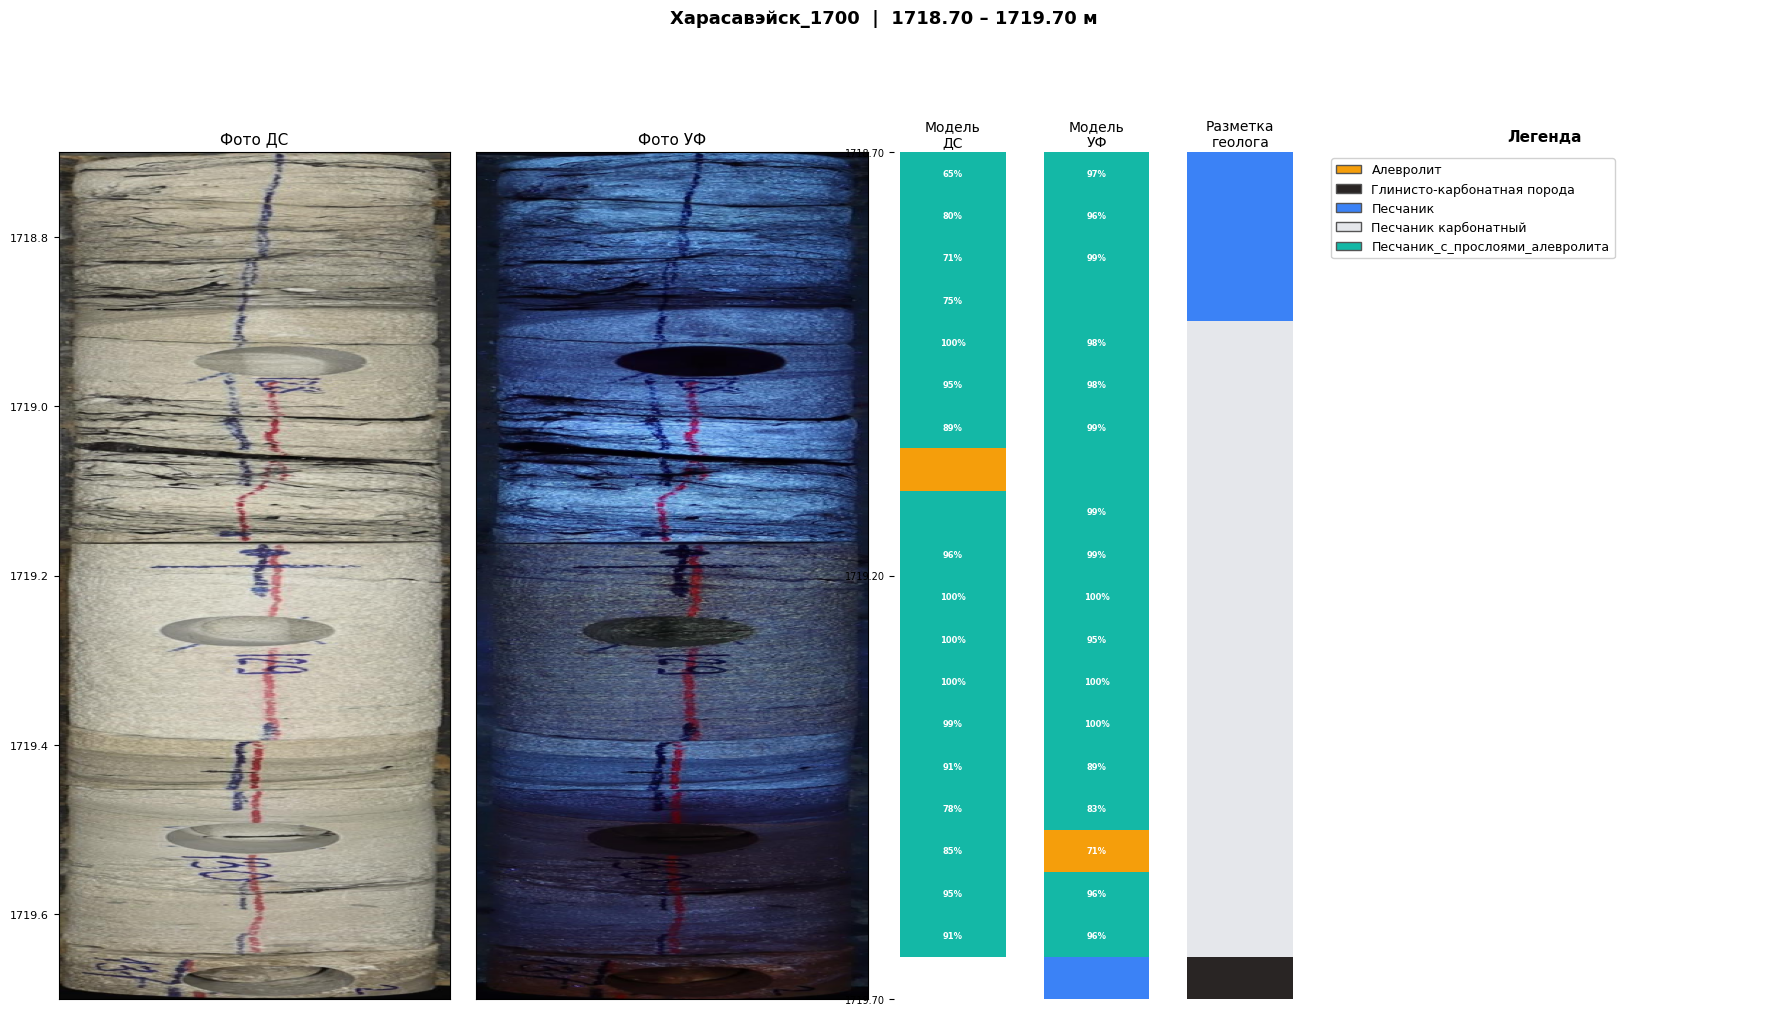

In [5]:
def visualize_photo(well_name: str, target_depth=None, save: bool = True):
    """
    Строит панель для каждого найденного фото:
    [Фото ДС] | [Фото УФ] | [Пред. ДС] | [Пред. УФ] | [Разметка] | [Легенда]
    """
    photos    = find_photos(well_name, target_depth)
    markup_df = load_markup(well_name)

    if not photos:
        print(f'Фото не найдено: {well_name}, depth={target_depth}')
        return

    for ds_path, uv_path, d_from, d_to in photos:
        img_ds = np.array(Image.open(ds_path).convert('RGB'))
        img_uv = np.array(Image.open(uv_path).convert('RGB')) if uv_path else img_ds

        preds_ds = predict_tiles(img_ds, 'ДС', d_from, d_to)
        preds_uv = predict_tiles(img_uv, 'УФ', d_from, d_to)

        # Разметка геолога
        sub = markup_df[(markup_df.depth_from < d_to) & (markup_df.depth_to > d_from)]
        markup_segs = []
        for _, row in sub.iterrows():
            y0  = max(row['depth_from'], d_from)
            y1  = min(row['depth_to'],   d_to)
            nm  = str(row['mineral']).strip()
            key = nm.replace(' ', '_')
            col = CLASS_PALETTE.get(key, CLASS_PALETTE.get(nm, CLASS_PALETTE['unknown']))
            if y1 - y0 > 0.001:
                markup_segs.append((y0, y1, col, nm, None))

        def p2segs(preds):
            return [(p['depth_from'], p['depth_to'],
                     IDX2COLOR[p['class_idx']], p['class_name'], p['conf'])
                    for p in preds]

        # ── Рисуем панель ─────────────────────────────────────────────────────
        fig = plt.figure(figsize=(22, 11))
        gs  = plt.GridSpec(1, 6, figure=fig, width_ratios=[2.5, 2.5, 0.75, 0.75, 0.75, 2.8],
                           wspace=0.10)

        extent = [0, 1, d_to, d_from]

        ax_ds = fig.add_subplot(gs[0, 0])
        ax_ds.imshow(img_ds, aspect='auto', extent=extent)
        ax_ds.set_title('Фото ДС', fontsize=11)
        ax_ds.set_xticks([])
        ax_ds.yaxis.set_tick_params(labelsize=8)

        ax_uv = fig.add_subplot(gs[0, 1])
        ax_uv.imshow(img_uv, aspect='auto', extent=extent)
        ax_uv.set_title('Фото УФ', fontsize=11)
        ax_uv.set_xticks([])
        ax_uv.set_yticks([])

        ax_pred_ds = fig.add_subplot(gs[0, 2])
        draw_strip(ax_pred_ds, p2segs(preds_ds), d_from, d_to, 'Модель\nДС', show_conf=True)
        ax_pred_ds.set_yticks([d_from, (d_from + d_to) / 2, d_to])
        ax_pred_ds.set_yticklabels(
            [f'{d_from:.2f}', f'{(d_from+d_to)/2:.2f}', f'{d_to:.2f}'], fontsize=7
        )

        ax_pred_uv = fig.add_subplot(gs[0, 3])
        draw_strip(ax_pred_uv, p2segs(preds_uv), d_from, d_to, 'Модель\nУФ', show_conf=True)
        ax_pred_uv.set_yticks([])

        ax_markup = fig.add_subplot(gs[0, 4])
        draw_strip(ax_markup, markup_segs, d_from, d_to, 'Разметка\nгеолога')
        ax_markup.set_yticks([])

        # Легенда — все уникальные классы на этом фото
        shown = {}
        for p in preds_ds + preds_uv:
            shown[p['class_name']] = IDX2COLOR[p['class_idx']]
        for _, _, color, name, _ in markup_segs:
            shown[name] = color

        ax_leg = fig.add_subplot(gs[0, 5])
        ax_leg.axis('off')
        ax_leg.set_title('Легенда', fontsize=11, fontweight='bold', pad=8)
        handles = [
            mpatches.Patch(facecolor=color, edgecolor='#555', label=name)
            for name, color in sorted(shown.items())
        ]
        ax_leg.legend(handles=handles, loc='upper left', fontsize=9,
                      frameon=True, framealpha=0.9, edgecolor='#ccc',
                      bbox_to_anchor=(0.0, 1.0))

        fig.suptitle(
            f'{well_name}  |  {d_from:.2f} – {d_to:.2f} м',
            fontsize=13, fontweight='bold', y=1.01
        )

        if save:
            safe_well = well_name.replace(' ', '_')
            out = VIS_DIR / f'{safe_well}_{d_from:.2f}-{d_to:.2f}_full.png'
            fig.savefig(out, dpi=150, bbox_inches='tight')
            print(f'Сохранено: {out}')

        plt.tight_layout()
        plt.show()


visualize_photo(WELL_NAME, TARGET_DEPTH)

## 5. Статистика модели на тест-сете

Сохраняется в `results/{run}/visual/stats/`

In [6]:
@torch.no_grad()
def collect_test_predictions(modality: str, batch_size: int = 64):
    """Прогоняет модель по тест-сету."""
    cfg     = MODEL_CONFIGS[modality]
    test_ds = tv_datasets.ImageFolder(
        DATASET_ROOT / modality / 'test',
        transform=get_transforms(cfg['resize'], cfg['aug'], is_train=False)
    )
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=(DEVICE.type == 'cuda'))

    model = MODELS[modality]
    all_labels, all_preds, all_probs = [], [], []
    for inputs, labels in loader:
        probs = F.softmax(model(inputs.to(DEVICE)), dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(axis=1))
        all_probs.append(probs)

    return np.array(all_labels), np.array(all_preds), np.vstack(all_probs), test_ds.classes


print('Сбор предсказаний на тест-сете...')
test_res = {}
for mod in MODALITIES:
    labels, preds, probs, class_names = collect_test_predictions(mod)
    test_res[mod] = {'labels': labels, 'preds': preds, 'probs': probs, 'class_names': class_names}
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'  {mod}: F1_macro={f1:.4f}  Acc={acc:.4f}  (n={len(labels)})')

Сбор предсказаний на тест-сете...
  ДС: F1_macro=0.3160  Acc=0.4687  (n=5456)
  УФ: F1_macro=0.2811  Acc=0.4457  (n=5456)


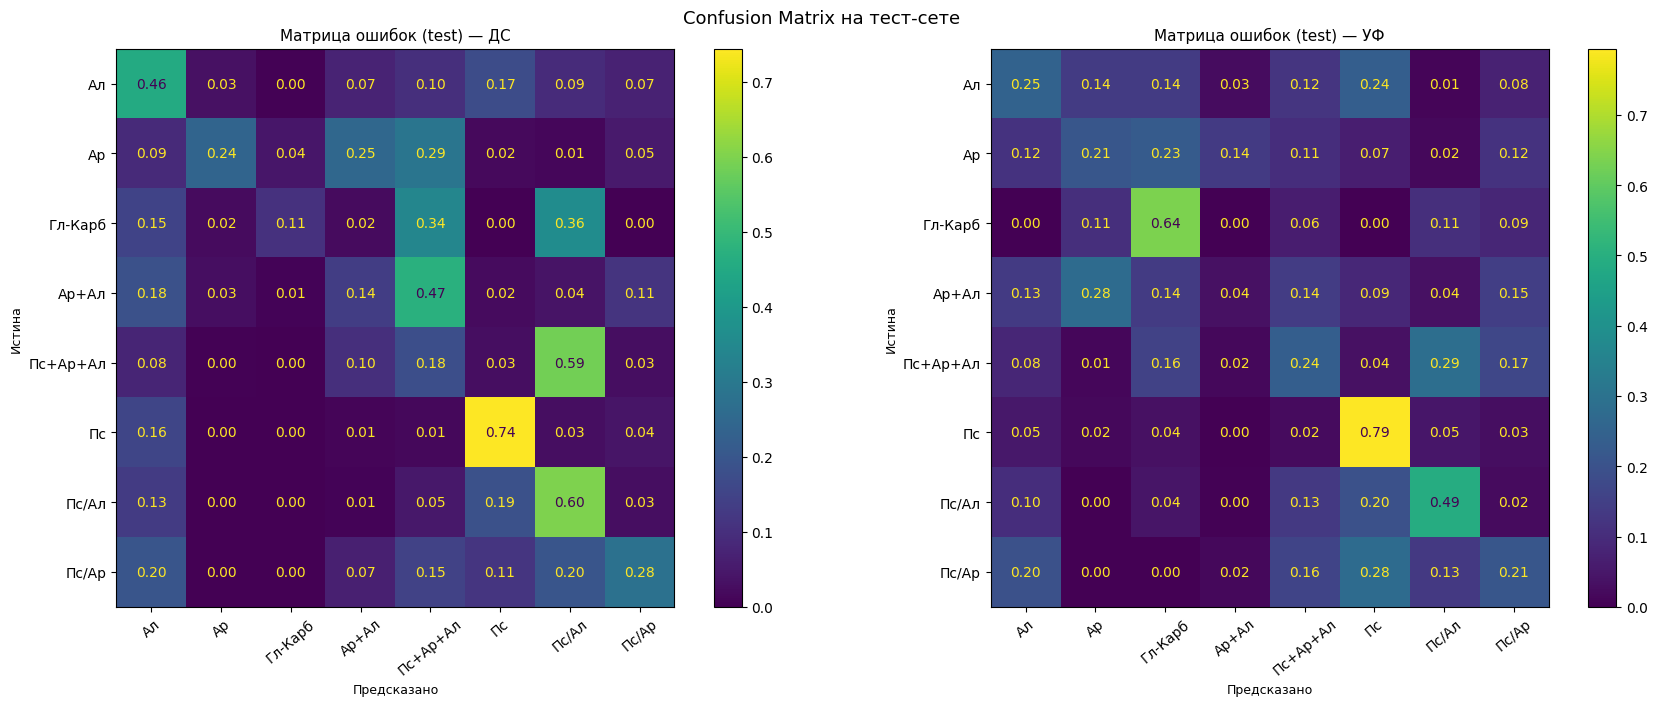

Сохранено: /var/lib/sadmin/Рабочий стол/kern/ML-Core-Kern-/old_results/two_models_v2/train_run_v2/visual/stats/confusion_test.png


In [7]:
# ── confusion_test_{mod}.png — матрица ошибок на тест-сете ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mod in zip(axes, MODALITIES):
    res   = test_res[mod]
    short = [CLASS_SHORT.get(c, c[:8]) for c in res['class_names']]
    cm    = confusion_matrix(res['labels'], res['preds'],
                             labels=list(range(len(res['class_names']))), normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=short)
    disp.plot(ax=ax, colorbar=True, xticks_rotation=40, values_format='.2f')
    ax.set_title(f'Матрица ошибок (test) — {mod}', fontsize=11)
    ax.set_xlabel('Предсказано', fontsize=9)
    ax.set_ylabel('Истина', fontsize=9)

plt.suptitle('Confusion Matrix на тест-сете', fontsize=13)
plt.tight_layout()
out = STATS_DIR / 'confusion_test.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {out}')

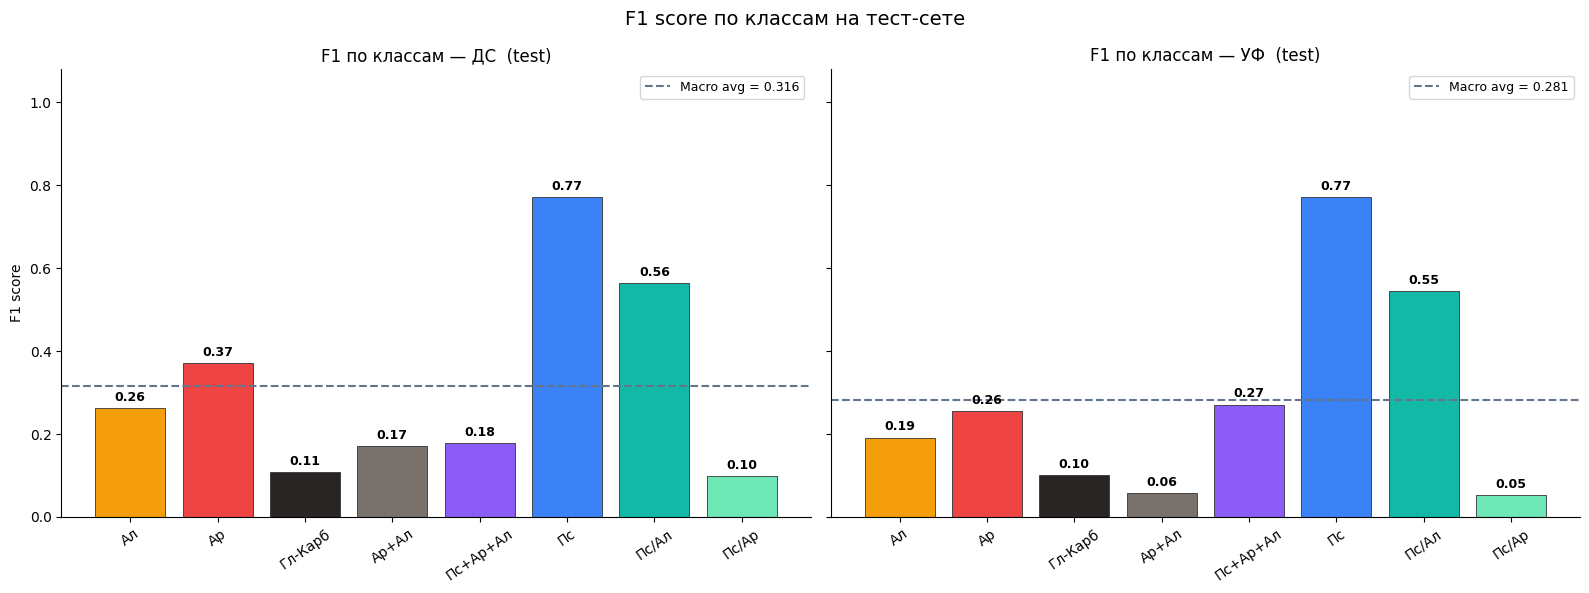

Сохранено: /var/lib/sadmin/Рабочий стол/kern/ML-Core-Kern-/old_results/two_models_v2/train_run_v2/visual/stats/per_class_f1_test.png


In [8]:
# ── per_class_f1_test.png — F1 по классам, ДС и УФ рядом ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, mod in zip(axes, MODALITIES):
    res        = test_res[mod]
    class_names = res['class_names']
    short      = [CLASS_SHORT.get(c, c[:10]) for c in class_names]
    colors     = [CLASS_PALETTE.get(c, '#94A3B8') for c in class_names]

    f1_per = f1_score(res['labels'], res['preds'],
                      labels=list(range(len(class_names))), average=None, zero_division=0)
    macro  = f1_per.mean()

    bars = ax.bar(short, f1_per, color=colors, edgecolor='#333', linewidth=0.6)
    for bar, val in zip(bars, f1_per):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.axhline(macro, color='#64748B', linestyle='--', linewidth=1.5,
               label=f'Macro avg = {macro:.3f}')
    ax.set_title(f'F1 по классам — {mod}  (test)', fontsize=12)
    ax.set_ylabel('F1 score' if ax == axes[0] else '')
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=9)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

plt.suptitle('F1 score по классам на тест-сете', fontsize=14)
plt.tight_layout()
out = STATS_DIR / 'per_class_f1_test.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {out}')

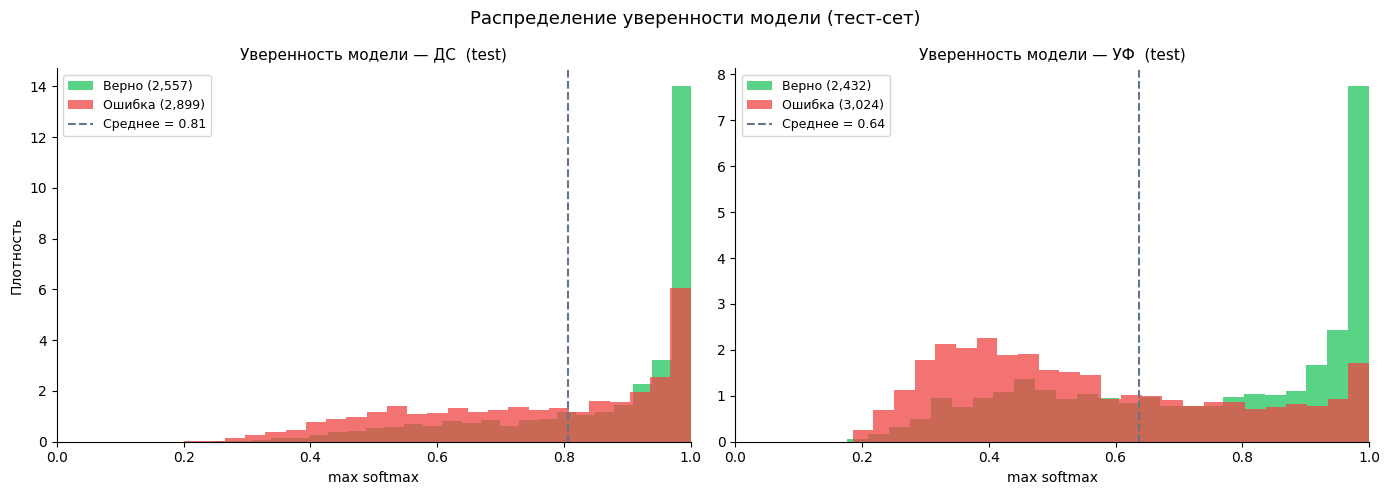

Сохранено: /var/lib/sadmin/Рабочий стол/kern/ML-Core-Kern-/old_results/two_models_v2/train_run_v2/visual/stats/confidence_distribution.png


In [9]:
# ── confidence_distribution.png — уверенность модели: верные vs ошибочные ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mod in zip(axes, MODALITIES):
    res       = test_res[mod]
    max_probs = res['probs'].max(axis=1)
    correct   = (res['labels'] == res['preds'])

    ax.hist(max_probs[correct],  bins=25, alpha=0.75, color='#22C55E',
            label=f'Верно ({correct.sum():,})', density=True)
    ax.hist(max_probs[~correct], bins=25, alpha=0.75, color='#EF4444',
            label=f'Ошибка ({(~correct).sum():,})', density=True)
    ax.axvline(max_probs.mean(), color='#64748B', linestyle='--', linewidth=1.5,
               label=f'Среднее = {max_probs.mean():.2f}')
    ax.set_title(f'Уверенность модели — {mod}  (test)', fontsize=11)
    ax.set_xlabel('max softmax', fontsize=10)
    ax.set_ylabel('Плотность' if ax == axes[0] else '')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

plt.suptitle('Распределение уверенности модели (тест-сет)', fontsize=13)
plt.tight_layout()
out = STATS_DIR / 'confidence_distribution.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {out}')

NameError: name 'precision_recall_fscore_support' is not defined

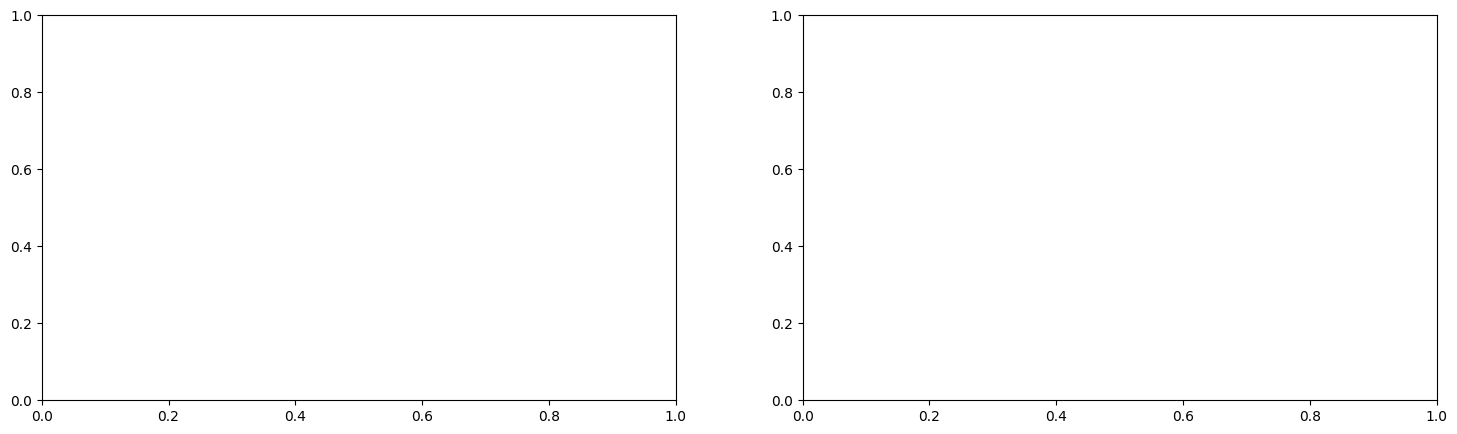

In [10]:
# ── classification_report.png — таблица precision/recall/F1 ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, mod in zip(axes, MODALITIES):
    res         = test_res[mod]
    class_names = res['class_names']
    short_names = [CLASS_SHORT.get(c, c[:10]) for c in class_names]

    prec, rec, f1_per, support = precision_recall_fscore_support(
        res['labels'], res['preds'],
        labels=list(range(len(class_names))), zero_division=0
    )
    macro_f1 = f1_score(res['labels'], res['preds'], average='macro', zero_division=0)
    acc      = accuracy_score(res['labels'], res['preds'])

    rows = [[sn, f'{p:.2f}', f'{r:.2f}', f'{f:.2f}', f'{s:,}']
            for sn, p, r, f, s in zip(short_names, prec, rec, f1_per, support)]
    rows.append(['— macro avg —', '', '', f'{macro_f1:.2f}', ''])
    rows.append([f'Accuracy: {acc:.3f}', '', '', '', f'{len(res["labels"]):,}'])

    ax.axis('off')
    tbl = ax.table(
        cellText=rows,
        colLabels=['Класс', 'Precision', 'Recall', 'F1', 'Support'],
        cellLoc='center', loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.0, 1.5)

    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#1E3A5F')
            cell.set_text_props(color='white', fontweight='bold')
        elif r >= len(class_names) + 1:
            cell.set_facecolor('#E2E8F0')
            cell.set_text_props(fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#F8FAFC')
        else:
            cell.set_facecolor('white')
        cell.set_edgecolor('#CBD5E1')

    ax.set_title(f'Classification Report — {mod}  (test)', fontsize=11, pad=12, fontweight='bold')

plt.suptitle('Precision / Recall / F1 на тест-сете', fontsize=13, y=1.02)
plt.tight_layout()
out = STATS_DIR / 'classification_report.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: {out}')

# Текстовый вывод в консоль
for mod in MODALITIES:
    res = test_res[mod]
    print(f'\n{"="*55}  {mod}  (test)')
    print(classification_report(res['labels'], res['preds'],
                                target_names=res['class_names'], zero_division=0))

## 6. Дополнительные фотографии (опционально)

In [ ]:
# Раскомментируйте нужную строку и запустите ячейку

# visualize_photo('Харасавэйск_1700', target_depth=1721.20)
# visualize_photo('Харасавэйск_1400', target_depth=None)   # тест-скважина, все фото
# visualize_photo('Ямбург_1 N',       target_depth=None)   # тест-скважина, все фото